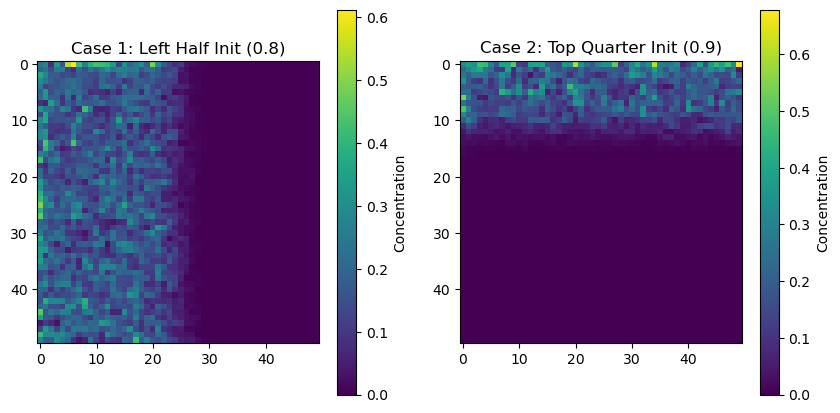

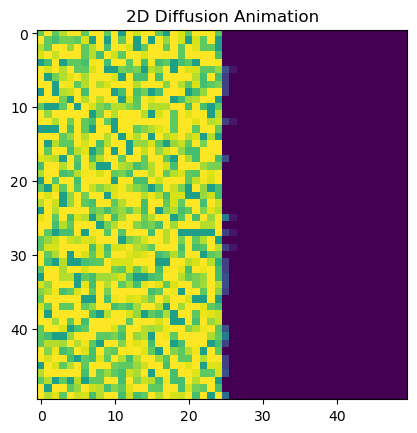

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

h, w = 50, 50   
steps = 50     
concentration1 = 0.8
concentration2 = 0.9

def diffuse(lattice, steps=1):
    for _ in range(steps):
        new_lattice = lattice.copy()
        for i in range(h):
            for j in range(w):
                if lattice[i, j] > 0:
                   
                    moves = [(0, 1), (0, -1), (1, 0), (-1, 0)]
                    di, dj = moves[np.random.randint(4)]
                    ni, nj = i + di, j + dj
                    if 0 <= ni < h and 0 <= nj < w:
                        new_lattice[ni, nj] += lattice[i, j] * 0.25
                        new_lattice[i, j] *= 0.75
        lattice = new_lattice
    return lattice
    
lattice1 = np.zeros((h, w))
lattice1[:, :w//2] = concentration1
result1 = diffuse(lattice1, steps=steps)

lattice2 = np.zeros((h, w))
lattice2[:h//4, :] = concentration2
result2 = diffuse(lattice2, steps=steps)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(result1, cmap='viridis')
plt.title(f'Case 1: Left Half Init ({concentration1})')
plt.colorbar(label='Concentration')

plt.subplot(1, 2, 2)
plt.imshow(result2, cmap='viridis')
plt.title(f'Case 2: Top Quarter Init ({concentration2})')
plt.colorbar(label='Concentration')

plt.show()

lattice_anim = np.zeros((h, w))
lattice_anim[:, :w//2] = concentration1

fig, ax = plt.subplots()
im = ax.imshow(lattice_anim, cmap='viridis', interpolation='none')
ax.set_title('2D Diffusion Animation')

def update(frame):
    global lattice_anim
    lattice_anim = diffuse(lattice_anim, steps=1)
    im.set_array(lattice_anim)
    return im,

ani = FuncAnimation(fig, update, frames=100, interval=100, blit=True)
plt.show()
